[Home](../../README.md)

### Data Wrangling

This is a demonstration of data wrangling using [Pandas](https://pandas.pydata.org/) the library for data analysis and manipulation.

This Jupyter Notepad demonstrates different processes you can apply to your data to prepare it for feature engineering and model training. For this demonstration we will wrangle the diabetes data set you previewed in the last Jupyter Notebook.

> [!Note]
> None of these processes are destructive to the source CSV as long as you save the modified data to a new CSV.

#### Load the required dependencies

In [1]:
# Import frameworks
import pandas as pd
import matplotlib.pyplot as plt

####  Store the data as a local variable

The data frame is a Pandas object that structures your tabular data into an appropriate format. It loads the complete data in memory so it is now ready for preprocessing.

In [2]:
data_frame = pd.read_csv("spotify_songs.csv")

####  Drop irrelevant columns

The data frame is a Pandas object that structures your tabular data into an appropriate format. It loads the complete data in memory so it is now ready for preprocessing. (fix later)

In [3]:
data_frame.columns


Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='str')

In [4]:
to_drop = [
    "track_id",
    "track_name",
    "track_artist",
    "track_album_id",
    "track_album_name",
    "playlist_name",
    "playlist_id",
    "playlist_genre",
    "playlist_subgenre"
]

print(to_drop)

all_to_drop = [i for i in to_drop if i in data_frame.columns]

data_frame = data_frame.drop(columns=all_to_drop)

print(data_frame.columns)

['track_id', 'track_name', 'track_artist', 'track_album_id', 'track_album_name', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre']
Index(['track_popularity', 'track_album_release_date', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='str')


In [5]:
data_frame = data_frame.rename(columns={"mode": "song_mode"})
data_frame.columns

Index(['track_popularity', 'track_album_release_date', 'danceability',
       'energy', 'key', 'loudness', 'song_mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='str')

In [6]:
data_frame.song_mode.unique()

array([1, 0])

In [7]:
data_frame["track_album_release_date"] = pd.to_datetime(
    data_frame["track_album_release_date"], format="mixed"
).dt.year

data_frame["track_album_release_date"] = (
    data_frame["track_album_release_date"]
    .fillna(data_frame["track_album_release_date"].mean())
    .astype(int)
)

print(data_frame["track_album_release_date"].unique())
print(data_frame["track_album_release_date"].info())

[2019 2018 2017 2016 2014 2012 2015 2013 2011 2010 2008 2020 2007 1998
 1996 1999 2009 1993 1995 1991 2000 1994 1992 1997 2001 2006 2002 2003
 2005 1990 2004 1988 1984 1982 1973 1979 1977 1981 1974 1970 1976 1987
 1978 1969 1986 1980 1983 1985 1989 1975 1968 1971 1972 1967 1966 1965
 1964 1963 1962 1957 1958 1961 1960]
<class 'pandas.Series'>
RangeIndex: 32833 entries, 0 to 32832
Series name: track_album_release_date
Non-Null Count  Dtype
--------------  -----
32833 non-null  int64
dtypes: int64(1)
memory usage: 256.6 KB
None


In [8]:
# Remove zero popularity tracks - these are likely unlisted/unavailable songs, not genuinely zero popular
print(f"Rows before: {len(data_frame)}")
zero_pop = (data_frame["track_popularity"] == 0).sum()
print(f"Zero popularity tracks removed: {zero_pop}")
data_frame = data_frame[data_frame["track_popularity"] != 0]
print(f"Rows after: {len(data_frame)}")

Rows before: 32833
Zero popularity tracks removed: 2703
Rows after: 30130


In [9]:
# Spotify defines speechiness > 0.66 as spoken word, not music
print(f"Rows before: {len(data_frame)}")
spoken_word = (data_frame["speechiness"] > 0.66).sum()
print(f"Spoken word tracks removed: {spoken_word}")
data_frame = data_frame[data_frame["speechiness"] <= 0.66]
print(f"Rows after: {len(data_frame)}")

Rows before: 30130
Spoken word tracks removed: 23
Rows after: 30107


#### Dealing with null values

Null values during data analysis can cause runtime errors and unexpected results. It is important to identify null values and deal with them appropriately before training a model.

The `isnull().sum()` method call returns the null values in any column.

In [10]:
data_frame.isnull().sum()

track_popularity            0
track_album_release_date    0
danceability                0
energy                      0
key                         0
loudness                    0
song_mode                   0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

If you have null data there are many ways to deal with the empty/null values. These are the two most common approaches.
1. Remove any row with a null value with a `dropna()` method call.
2. Replace missing values with another value with a `fillna()` method call. Generally, we use mean value for numerical columns because it may cause minimal changes in your mathematical analysis while maintaining the original size of the data.

Students should reflect why this example removes the null 'SEX' but replacing the mean 'Target'?

In [11]:
# Remove Null values
#data_frame = data_frame.dropna(subset=['SEX'])
#data_frame.isnull().sum()

In [12]:
# Replace Null values with the mean value for the column
#data_frame['Target'] = data_frame['Target'].fillna(data_frame['Target'].mean())
#data_frame.isnull().sum()

#### Remove Duplicates

Duplicate data can have detrimental effects on your machine learning models and outcomes, such as reducing data diversity and representativeness, which can lead to overfitting or biased models.

The `duplicated().sum()` method call returns the count of duplicate rows in the data frame.

In [13]:
data_frame.duplicated().sum()

np.int64(4407)

In [14]:
duplicate_mask = data_frame.duplicated()
print(data_frame.loc[duplicate_mask])

       track_popularity  track_album_release_date  danceability  energy  key  \
1299                 93                      2019         0.505   0.340    4   
1300                 98                      2019         0.764   0.320   11   
1304                 94                      2019         0.501   0.405    1   
1305                 88                      2019         0.759   0.548    9   
1307                 96                      2019         0.721   0.716   10   
...                 ...                       ...           ...     ...  ...   
32783                64                      2014         0.606   0.720    5   
32793                52                      2014         0.496   0.789    1   
32798                67                      2011         0.507   0.665    0   
32804                 1                      2013         0.479   0.675    9   
32808                54                      2012         0.712   0.497   11   

       loudness  song_mode  speechiness

The `drop_duplicates()` method call can be then stored back onto the data_frame variable removing the duplicates.

In [15]:
data_frame = data_frame.drop_duplicates()
data_frame.duplicated().sum()

np.int64(0)

In [16]:
data_frame.info()

<class 'pandas.DataFrame'>
Index: 25700 entries, 0 to 32832
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_popularity          25700 non-null  int64  
 1   track_album_release_date  25700 non-null  int64  
 2   danceability              25700 non-null  float64
 3   energy                    25700 non-null  float64
 4   key                       25700 non-null  int64  
 5   loudness                  25700 non-null  float64
 6   song_mode                 25700 non-null  int64  
 7   speechiness               25700 non-null  float64
 8   acousticness              25700 non-null  float64
 9   instrumentalness          25700 non-null  float64
 10  liveness                  25700 non-null  float64
 11  valence                   25700 non-null  float64
 12  tempo                     25700 non-null  float64
 13  duration_ms               25700 non-null  int64  
dtypes: float64(9), int64(5

#### Replace data

We can run a lambda function on a column to modify its values. For a simple example, let’s convert the Sex to lowercase. To run a function over a complete column, we can use the apply method which iterates over each row and modifies the values.

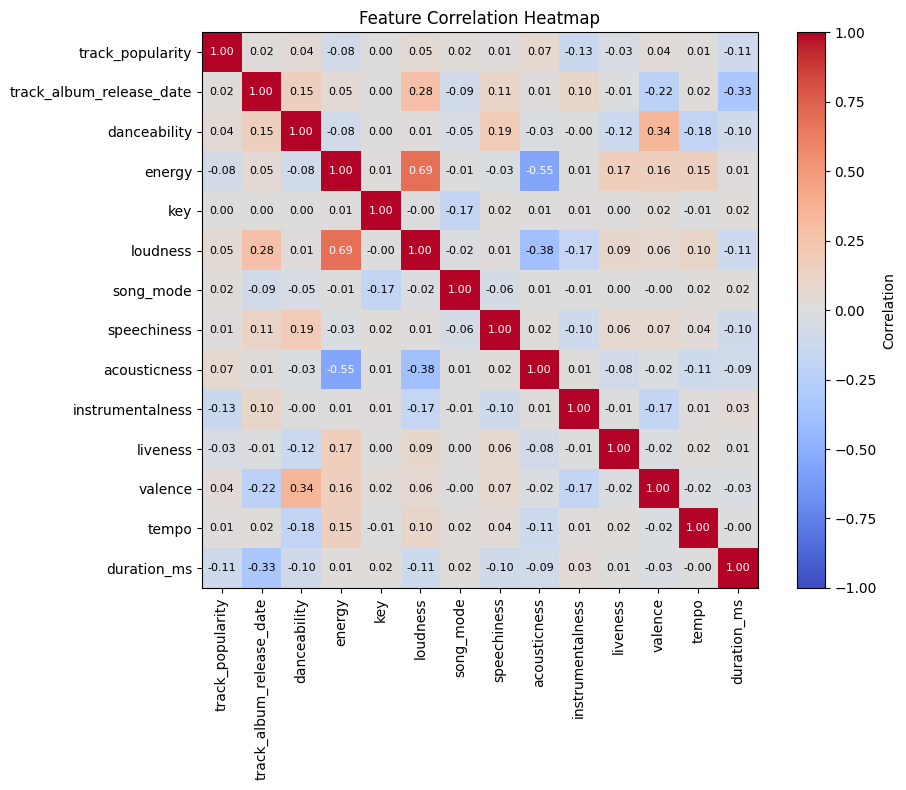

In [17]:
corr = data_frame.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        text_color = "white" if abs(value) > 0.5 else "black"
        plt.text(
            j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8
        )
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

We can check that there are no data entry errors by the `unique()` method call.

#### Remove outliers

Outliers can skew your analysis on numerical columns, and it is important to remove them. We can use the 25th and 75th quartile on numerical data, to get the inter-quartile range. This allows us to estimate an acceptable range, and we can then filter out any values outside this range. Mathematically, outliers are values occurring outside 1.5 times the interquartile range (IQR) from the first quartile (Q1) or third quartile (Q3).

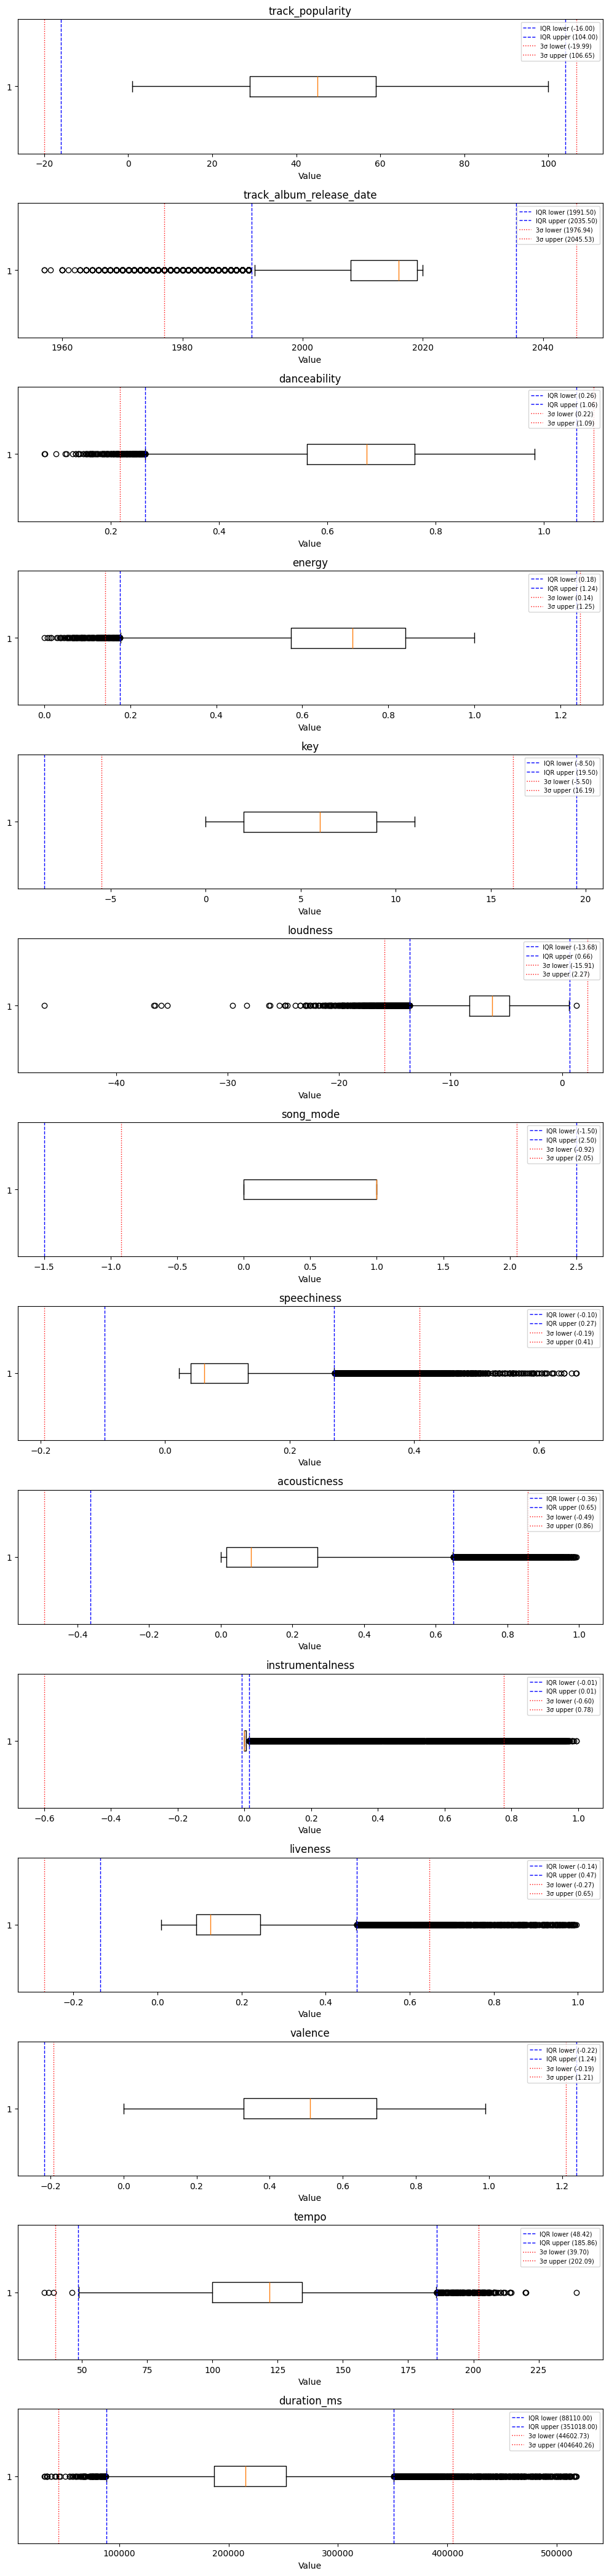

In [18]:
# Boxplot of all numerical columns visualising IQR and 3-sigma outlier bounds
numerical_cols = data_frame.select_dtypes(include="number").columns

fig, axes = plt.subplots(
    nrows=len(numerical_cols), ncols=1, figsize=(10, len(numerical_cols) * 3)
)

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(data_frame[col].dropna(), vert=False)

    # IQR bounds
    Q1 = data_frame[col].quantile(0.25)
    Q3 = data_frame[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_lower = Q1 - 1.5 * IQR
    iqr_upper = Q3 + 1.5 * IQR

    # 3-sigma bounds
    mean = data_frame[col].mean()
    std = data_frame[col].std()
    sigma_lower = mean - 3 * std
    sigma_upper = mean + 3 * std

    axes[i].axvline(
        iqr_lower,
        color="blue",
        linestyle="--",
        linewidth=1,
        label=f"IQR lower ({iqr_lower:.2f})",
    )
    axes[i].axvline(
        iqr_upper,
        color="blue",
        linestyle="--",
        linewidth=1,
        label=f"IQR upper ({iqr_upper:.2f})",
    )
    axes[i].axvline(
        sigma_lower,
        color="red",
        linestyle=":",
        linewidth=1,
        label=f"3σ lower ({sigma_lower:.2f})",
    )
    axes[i].axvline(
        sigma_upper,
        color="red",
        linestyle=":",
        linewidth=1,
        label=f"3σ upper ({sigma_upper:.2f})",
    )

    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()

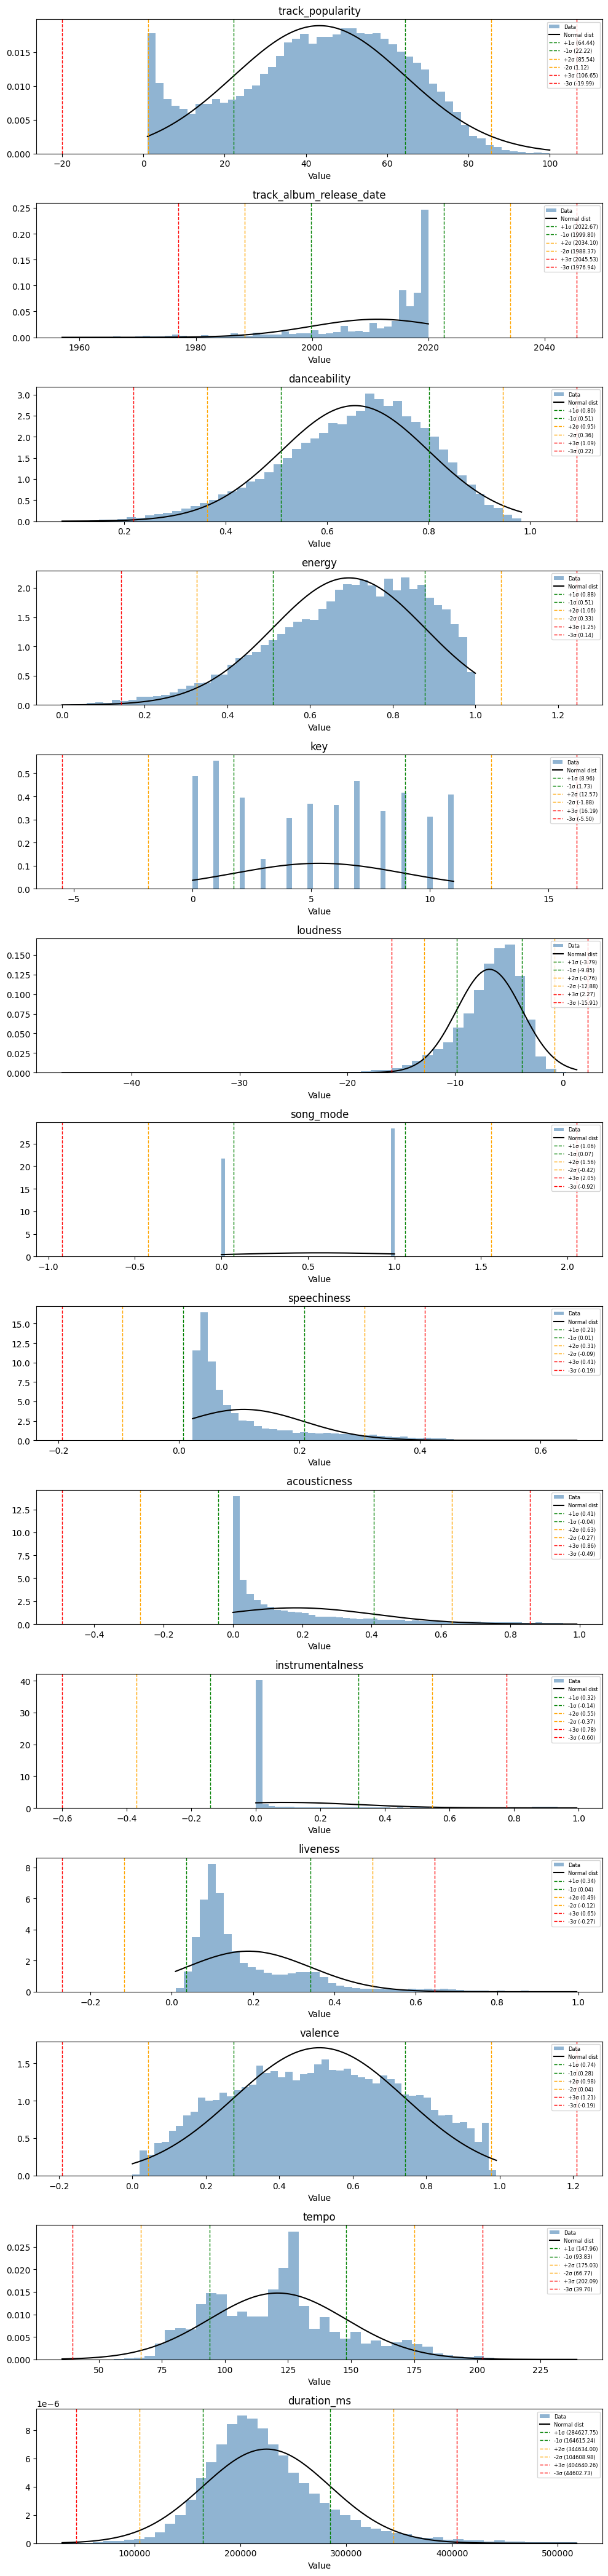

In [19]:
# Histogram with normal distribution curve and 3-sigma bounds for all numerical columns
import numpy as np
from scipy.stats import norm

numerical_cols = data_frame.select_dtypes(include="number").columns

fig, axes = plt.subplots(
    nrows=len(numerical_cols), ncols=1, figsize=(10, len(numerical_cols) * 3)
)

for i, col in enumerate(numerical_cols):
    data = data_frame[col].dropna()
    mean = data.mean()
    std = data.std()

    # Histogram
    axes[i].hist(
        data, bins=50, density=True, alpha=0.6, color="steelblue", label="Data"
    )

    # Normal distribution curve
    x = np.linspace(data.min(), data.max(), 200)
    axes[i].plot(
        x, norm.pdf(x, mean, std), color="black", linewidth=1.5, label="Normal dist"
    )

    # 3-sigma bounds
    for n, color in zip([1, 2, 3], ["green", "orange", "red"]):
        axes[i].axvline(
            mean + n * std,
            color=color,
            linestyle="--",
            linewidth=1,
            label=f"+{n}σ ({mean + n*std:.2f})",
        )
        axes[i].axvline(
            mean - n * std,
            color=color,
            linestyle="--",
            linewidth=1,
            label=f"-{n}σ ({mean - n*std:.2f})",
        )

    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].legend(fontsize=6, loc="upper right")

plt.tight_layout()
plt.show()

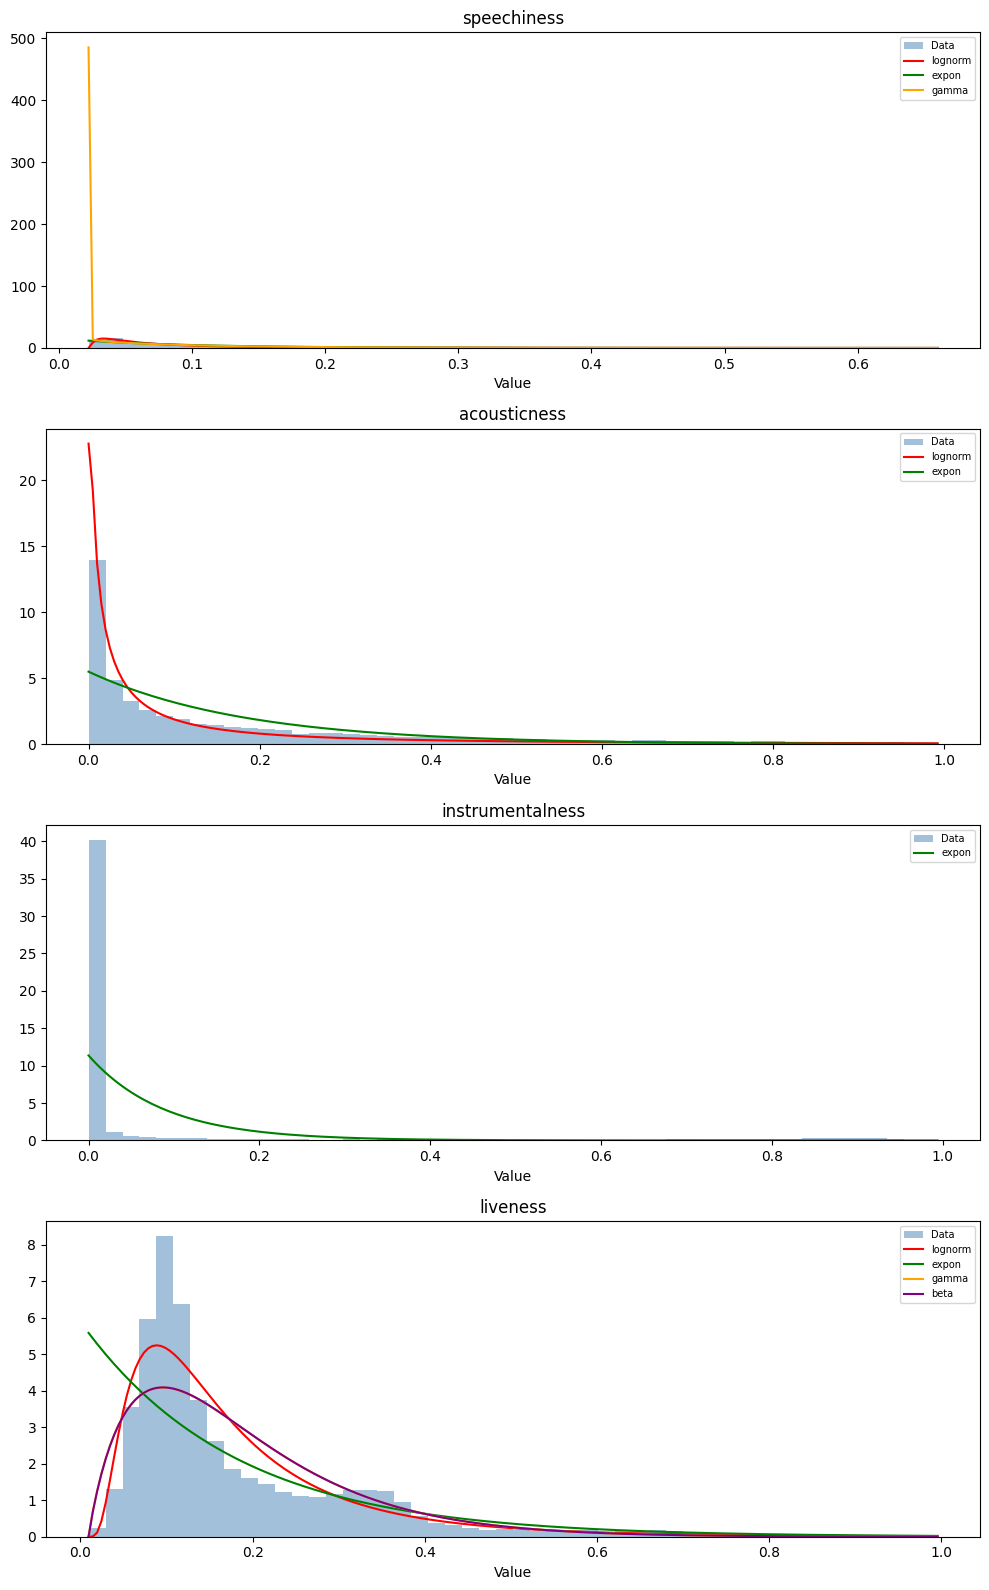

In [20]:
# Distribution fitting for skewed columns
import warnings
from scipy import stats

skewed_cols = ["speechiness", "acousticness", "instrumentalness", "liveness", ]

distributions = [
    stats.lognorm,
    stats.expon,
    stats.gamma,
    stats.beta,
]

fig, axes = plt.subplots(
    nrows=len(skewed_cols), ncols=1, figsize=(10, len(skewed_cols) * 4)
)

for i, col in enumerate(skewed_cols):
    data = data_frame[col].dropna()

    # Histogram
    axes[i].hist(
        data, bins=50, density=True, alpha=0.5, color="steelblue", label="Data"
    )

    x = np.linspace(data.min(), data.max(), 200)

    # Fit and plot each distribution
    colors = ["red", "green", "orange", "purple"]
    for dist, color in zip(distributions, colors):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                params = dist.fit(data)
                pdf_values = dist.pdf(x, *params)
                # Only plot if the result is finite and reasonable
                if np.all(np.isfinite(pdf_values)) and np.max(pdf_values) < 1000:
                    axes[i].plot(
                        x, pdf_values, color=color, linewidth=1.5, label=dist.name
                    )
        except Exception:
            pass

    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [21]:
# # Get the inter-quartile range for all numerical columns
# numerical_cols = data_frame.select_dtypes(include="number").columns

# for col in numerical_cols:
#     Q1 = data_frame[col].quantile(0.25)
#     Q3 = data_frame[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - IQR * 1.5
#     upper_bound = Q3 + IQR * 1.5
#     outlier_count = (
#         (data_frame[col] < lower_bound) | (data_frame[col] > upper_bound)
#     ).sum()
#     print(f"\n{col}:")
#     print(f"  Outliers are above {upper_bound:.4f} or below {lower_bound:.4f}")
#     print(f"  Number of outliers: {outlier_count}")
# # ...existing code...
# Check outliers - skip binary/categorical columns where IQR is not meaningful
skip_cols = [
    "song_mode",  # binary 0/1
    "key",  # categorical 0-11
    "track_album_release_date",  # skewed, old songs are valid data
    "track_popularity",  # already cleaned (zero removal), IQR bounds exceed 0-100 range
    "speechiness",  # right-skewed, IQR upper bound 0.27 removes valid rap tracks
    "acousticness",  # right-skewed, IQR removes valid acoustic songs
    "instrumentalness",  # heavily right-skewed, IQR upper bound 0.014 removes ~5500 valid rows
    "liveness",  # right-skewed, IQR lower bound is negative (impossible value)
    "valence",  # already 0 outliers, no action needed
]
continuous_cols = [
    col
    for col in data_frame.select_dtypes(include="number").columns
    if col not in skip_cols
]

for col in continuous_cols:
    Q1 = data_frame[col].quantile(0.25)
    Q3 = data_frame[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - IQR * 1.5
    upper_bound = Q3 + IQR * 1.5
    outlier_count = (
        (data_frame[col] < lower_bound) | (data_frame[col] > upper_bound)
    ).sum()
    print(f"\n{col}:")
    print(f"  Outliers are above {upper_bound:.4f} or below {lower_bound:.4f}")
    print(f"IQR: {IQR}")
    print(f"  Number of outliers: {outlier_count}")


danceability:
  Outliers are above 1.0595 or below 0.2635
IQR: 0.19899999999999995
  Number of outliers: 232

energy:
  Outliers are above 1.2365 or below 0.1765
IQR: 0.265
  Number of outliers: 194

loudness:
  Outliers are above 0.6585 or below -13.6815
IQR: 3.585
  Number of outliers: 778

tempo:
  Outliers are above 185.8625 or below 48.4185
IQR: 34.361000000000004
  Number of outliers: 427

duration_ms:
  Outliers are above 351018.0000 or below 88110.0000
IQR: 65727.0
  Number of outliers: 1103


In [22]:
# Remove outliers for continuous columns only
print(f"Rows before: {len(data_frame)}")

for col in continuous_cols:
    Q1 = data_frame[col].quantile(0.25)
    Q3 = data_frame[col].quantile(0.75)
    IQR = Q3 - Q1
    data_frame = data_frame[
        (data_frame[col] >= Q1 - 1.5 * IQR) & (data_frame[col] <= Q3 + 1.5 * IQR)
    ]

print(f"Rows after: {len(data_frame)}")
print(data_frame.describe())

Rows before: 25700
Rows after: 23180
       track_popularity  track_album_release_date  danceability        energy  \
count      23180.000000              23180.000000  23180.000000  23180.000000   
mean          43.805349               2011.828861      0.662577      0.707956   
std           21.054753                 10.794493      0.137691      0.169098   
min            1.000000               1957.000000      0.264000      0.181000   
25%           30.000000               2009.000000      0.571000      0.592000   
50%           46.000000               2017.000000      0.676000      0.726000   
75%           60.000000               2019.000000      0.764000      0.843000   
max          100.000000               2020.000000      0.981000      0.999000   

                key      loudness     song_mode   speechiness  acousticness  \
count  23180.000000  23180.000000  23180.000000  23180.000000  23180.000000   
mean       5.334297     -6.432985      0.562683      0.107503      0.171554

#### Scaling features to a common range

Scaling the features makes it easier for machine learning algorithms to find the optimal solution, as the different scales of the features do not influence them.

In [23]:
# Scale all numerical features to [0, 1] range using min-max scaling
scaling_records = {}

# Skip binary and categorical columns that are not meaningful to scale
skip_scaling = [
    "song_mode",  # binary 0/1
    "key",  # categorical 0-11, not ordinal
    "track_album_release_date",  # year values, ordinal but not a feature for prediction
]

numerical_cols = [
    col for col in data_frame.select_dtypes(include="number").columns
    if col not in skip_scaling
]

for col in numerical_cols:
    col_min = data_frame[col].min()
    col_max = data_frame[col].max()
    data_frame[col] = [(X - col_min) / (col_max - col_min) for X in data_frame[col]]
    scaling_records[col] = {"min": col_min, "max": col_max}
    print(f"{col}: min={col_min:.4f}, max={col_max:.4f}")

print("\nScaling complete.")
data_frame.describe()

track_popularity: min=1.0000, max=100.0000
danceability: min=0.2640, max=0.9810
energy: min=0.1810, max=0.9990
loudness: min=-13.5120, max=0.5510
speechiness: min=0.0224, max=0.6600
acousticness: min=0.0000, max=0.9890
instrumentalness: min=0.0000, max=0.9870
liveness: min=0.0094, max=0.9940
valence: min=0.0292, max=0.9910
tempo: min=48.9810, max=185.0440
duration_ms: min=90380.0000, max=348527.0000

Scaling complete.


,track_popularity,track_album_release_date,danceability,energy,key,loudness,song_mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,23180.000000,23180.000000,23180.000000,23180.000000,23180.000000,23180.000000,23180.000000,23180.000000,23180.000000,23180.000000,23180.000000,23180.000000,23180.000000,23180.000000
mean,0.432377,2011.828861,0.555895,0.644201,5.334297,0.503379,0.562683,0.133474,0.173461,0.073623,0.183225,0.505729,0.519789,0.493274
std,0.212674,10.794493,0.192037,0.206721,3.612601,0.175701,0.496066,0.156730,0.212859,0.209338,0.154470,0.239949,0.185570,0.178892
min,0.000000,1957.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.292929,2009.000000,0.428173,0.502445,2.000000,0.398208,0.000000,0.029329,0.016075,0.000000,0.084945,0.320025,0.374031,0.370409
50%,0.454545,2017.000000,0.574616,0.666259,6.000000,0.528337,1.000000,0.064068,0.082304,0.000011,0.120491,0.507174,0.525830,0.475349
75%,0.595960,2019.000000,0.697350,0.809291,8.000000,0.631800,1.000000,0.175031,0.255813,0.003080,0.242363,0.693283,0.613164,0.602110
max,1.000000,2020.000000,1.000000,1.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


> [!important]
> You need to save the calculations for each dataset you scale for scaling new values for prediction. Use [2.1.2.data.records.md](2.1.2.data.records.md) to record this information.

#### Save the wrangled data to CSV

In [24]:
data_frame.to_csv('../2.2.Feature_Engineering/wrangled_data.csv', index=False)